In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shuofxz/titanic-machine-learning-from-disaster/train.csv
/kaggle/input/datasets/shuofxz/titanic-machine-learning-from-disaster/test.csv


In [2]:
!pip install numpy pandas matplotlib scikit-learn seaborn

# DATA EXPLORATION

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Meaning of each columns:

- PassengerId- Unique is identifier for each passenger (just a row number)
- Survived- whether the passenger survived the sinking or not (the target variable you usually try to predict)
- Pclass- Ticket class (a proxy for socio-economic status)
- SibSp- Number of siblings or spouses the passenger had aboard the Titanic
- Parch- Number of parents or children the passenger had aboard the Titanic
- Ticket- Ticket number
- Fare- Passenger fare (price paid for the ticket)
- Cabin- Cabin number
- Embarked- Port where the passenger embarked (boarded the ship)

In [4]:
df = pd.read_csv('/kaggle/input/datasets/shuofxz/titanic-machine-learning-from-disaster/train.csv')

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
# no of classes in survived
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [6]:
# no of classes in cabin
df['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [7]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [8]:
# Drop columns
df = df.drop(['PassengerId', 'Name','Ticket', 'Cabin'], axis = 1)

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [9]:
'''
Sex- label encoding, Embarked- mapping
'''
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [10]:
embarked_mapping = {
    'S': 0,
    'C': 1,
    'Q': 2
}

df['Embarked'] = df['Embarked'].map(embarked_mapping)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0.0
1,1,1,0,38.0,1,0,71.2833,1.0
2,1,3,0,26.0,0,0,7.9250,0.0
3,1,1,0,35.0,1,0,53.1000,0.0
4,0,3,1,35.0,0,0,8.0500,0.0


array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>,
        <Axes: title={'center': 'Sex'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>,
        <Axes: title={'center': 'Embarked'}>, <Axes: >]], dtype=object)

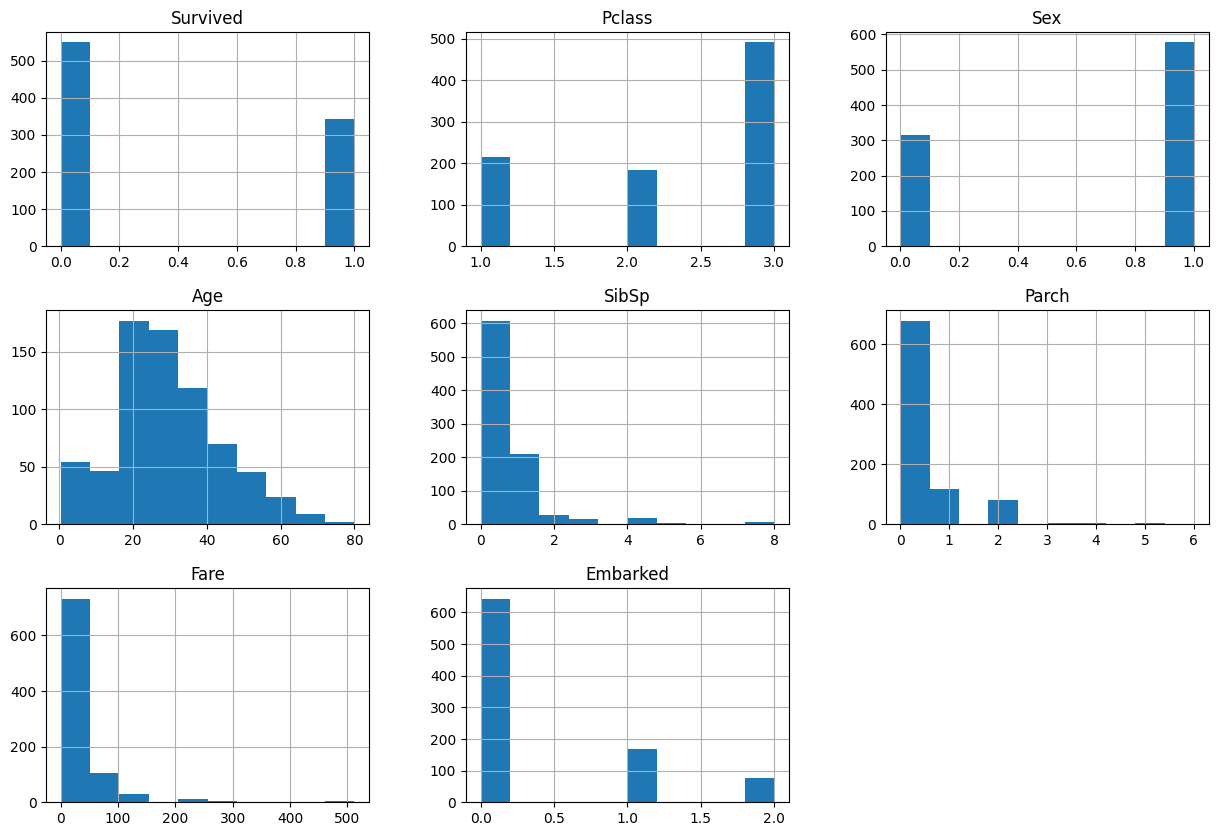

In [11]:
df.hist(figsize = (15, 10))

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 55.8 KB


In [13]:
!pip install seaborn matplotlib

<Axes: >

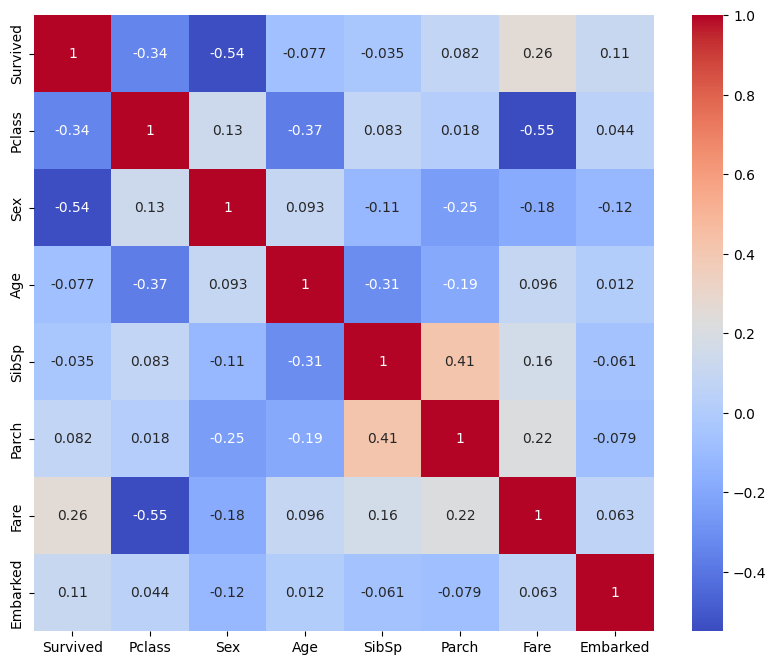

In [14]:
# Feature correlation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

# MODEL TRAINING

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size = 0.2)

In [16]:
# Split dataframes into features and target
train_X = train_df.drop('Survived', axis = 1)
train_y = train_df['Survived']

test_X = test_df.drop('Survived', axis = 1)
test_y = test_df['Survived']

In [17]:
forest = RandomForestClassifier()
forest.fit(train_X, train_y)

RandomForestClassifier()

In [18]:
forest.score(test_X, test_y)

0.7821229050279329

In [19]:
# For sorted importances
importances = dict(zip(forest.feature_names_in_, forest.feature_importances_))
importances = {k:v for k,v in sorted(importances.items(), key = lambda x:x[1], reverse = True)}

importances

{'Sex': np.float64(0.26019923445845805),
 'Age': np.float64(0.25861514863722124),
 'Fare': np.float64(0.25626181729897163),
 'Pclass': np.float64(0.10215662150385171),
 'SibSp': np.float64(0.043631413937828115),
 'Parch': np.float64(0.04242075838051901),
 'Embarked': np.float64(0.03671500578315012)}

In [20]:
import joblib

joblib.dump(forest, 'random_forest_model.joblib')

['random_forest_model.joblib']